In [2]:
import pandas as pd
import numpy as np
import random
import json
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, hamming_loss
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
print('✅ Imports done')

✅ Imports done


In [50]:
# Full required skill set per role
ROLE_SKILLS = {
    "Data Scientist": [
        "Python", "SQL", "Machine Learning", "Pandas", "NumPy",
        "Statistics", "Data Visualization", "Scikit-learn", "Model Deployment", "Feature Engineering"
    ],
    "Software Engineer": [
        "Java", "DSA", "OOP", "Git", "System Design",
        "REST APIs", "Unit Testing", "SQL", "Linux", "Docker"
    ],
    "Cloud Engineer": [
        "Linux", "AWS", "Docker", "Kubernetes", "Networking",
        "Terraform", "CI/CD", "Shell Scripting", "Azure", "Security"
    ],
    "Data Analyst": [
        "Excel", "SQL", "Power BI", "Python", "Statistics",
        "Data Cleaning", "Tableau", "Communication", "Pandas", "Data Visualization"
    ],
    "AI Engineer": [
        "Python", "Machine Learning", "Deep Learning", "Pandas", "Model Deployment",
        "PyTorch", "TensorFlow", "LLMs", "MLOps", "Feature Engineering"
    ],
    "Frontend Developer": [
        "HTML", "CSS", "JavaScript", "React", "TypeScript",
        "Git", "REST APIs", "Responsive Design", "Testing", "Webpack"
    ],
    "Backend Developer": [
        "Python", "Java", "SQL", "REST APIs", "Docker",
        "System Design", "Authentication", "Git", "Redis", "Linux"
    ],
    "DevOps Engineer": [
        "Linux", "Docker", "Kubernetes", "CI/CD", "Git",
        "AWS", "Monitoring", "Shell Scripting", "Ansible", "Terraform"
    ],
    "Cybersecurity Analyst": [
        "Networking", "Linux", "Security", "Ethical Hacking", "Cryptography",
        "SIEM Tools", "Risk Assessment", "Python", "Incident Response", "Firewalls"
    ],
    "ML Engineer": [
        "Python", "Machine Learning", "Scikit-learn", "MLOps", "Docker",
        "Feature Engineering", "SQL", "Model Deployment", "PyTorch", "TensorFlow"
    ]
}

# All unique skills across all roles
ALL_SKILLS = sorted(set(skill for skills in ROLE_SKILLS.values() for skill in skills))
ROLES = list(ROLE_SKILLS.keys())

print(f'Total roles: {len(ROLES)}')
print(f'Total unique skills: {len(ALL_SKILLS)}')
print(f'Skills: {ALL_SKILLS}')

Total roles: 10
Total unique skills: 55
Skills: ['AWS', 'Ansible', 'Authentication', 'Azure', 'CI/CD', 'CSS', 'Communication', 'Cryptography', 'DSA', 'Data Cleaning', 'Data Visualization', 'Deep Learning', 'Docker', 'Ethical Hacking', 'Excel', 'Feature Engineering', 'Firewalls', 'Git', 'HTML', 'Incident Response', 'Java', 'JavaScript', 'Kubernetes', 'LLMs', 'Linux', 'MLOps', 'Machine Learning', 'Model Deployment', 'Monitoring', 'Networking', 'NumPy', 'OOP', 'Pandas', 'Power BI', 'PyTorch', 'Python', 'REST APIs', 'React', 'Redis', 'Responsive Design', 'Risk Assessment', 'SIEM Tools', 'SQL', 'Scikit-learn', 'Security', 'Shell Scripting', 'Statistics', 'System Design', 'Tableau', 'TensorFlow', 'Terraform', 'Testing', 'TypeScript', 'Unit Testing', 'Webpack']


In [51]:
def generate_dataset(n=5000):
    rows = []
    for _ in range(n):
        role = random.choice(ROLES)
        required = ROLE_SKILLS[role]
        
        # User knows between 10%-90% of required skills
        num_known = random.randint(1, len(required) - 1)
        known = random.sample(required, num_known)
        
        # Add some random non-relevant skills (noise — realistic)
        extra_pool = [s for s in ALL_SKILLS if s not in required]
        num_extra = random.randint(0, 3)
        known += random.sample(extra_pool, min(num_extra, len(extra_pool)))
        
        # Binary vector of skills user has
        has_skill = {s: int(s in known) for s in ALL_SKILLS}
        
        # Binary vector of missing required skills (target)
        missing = {f"miss_{s}": int(s in required and s not in known) for s in ALL_SKILLS}
        
        row = {"Target_Role": role}
        row.update(has_skill)
        row.update(missing)
        rows.append(row)
    
    return pd.DataFrame(rows)

df = generate_dataset(5000)

# Save the dataset
df.to_csv("skill_gap_dataset_v2.csv", index=False)
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (5000, 111)


,Target_Role,AWS,Ansible,Authentication,Azure,CI/CD,CSS,Communication,Cryptography,DSA,...,miss_Shell Scripting,miss_Statistics,miss_System Design,miss_Tableau,miss_TensorFlow,miss_Terraform,miss_Testing,miss_TypeScript,miss_Unit Testing,miss_Webpack
0,Software Engineer,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,Cloud Engineer,1,0,1,1,0,1,0,0,1,...,1,0,0,0,0,1,0,0,0,0
2,Data Analyst,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0


Role distribution:
Target_Role
Frontend Developer       534
Data Scientist           516
Backend Developer        509
Cybersecurity Analyst    498
DevOps Engineer          496
Software Engineer        493
ML Engineer              493
AI Engineer              490
Cloud Engineer           489
Data Analyst             482
Name: count, dtype: int64


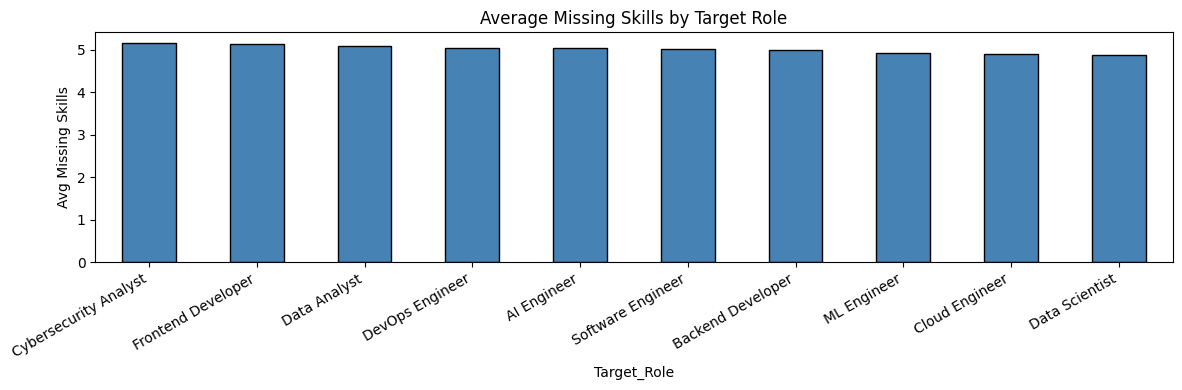

In [52]:
# Quick EDA
print('Role distribution:')
print(df['Target_Role'].value_counts())

# Average missing skills per role
miss_cols = [c for c in df.columns if c.startswith('miss_')]
df['total_missing'] = df[miss_cols].sum(axis=1)

avg_missing = df.groupby('Target_Role')['total_missing'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
avg_missing.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Missing Skills by Target Role')
plt.ylabel('Avg Missing Skills')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [53]:
# Encode Target_Role as one-hot
le = LabelEncoder()
df['Role_Encoded'] = le.fit_transform(df['Target_Role'])

skill_cols = ALL_SKILLS  # input features: user's current skills
miss_cols  = [f"miss_{s}" for s in ALL_SKILLS]  # output: which skills are missing

X = pd.get_dummies(df[['Target_Role'] + skill_cols], columns=['Target_Role'])
y = df[miss_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.shape}')

X_train: (4000, 65), y_train: (4000, 55)
X_test:  (1000, 65),  y_test:  (1000, 55)


In [54]:
# Multi-output Random Forest (one tree per missing skill label)
base_clf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
model = MultiOutputClassifier(base_clf, n_jobs=-1)

model.fit(X_train, y_train)
print('✅ Model trained!')

✅ Model trained!


Hamming Loss (lower is better): 0.0004
Subset Accuracy: 0.9840


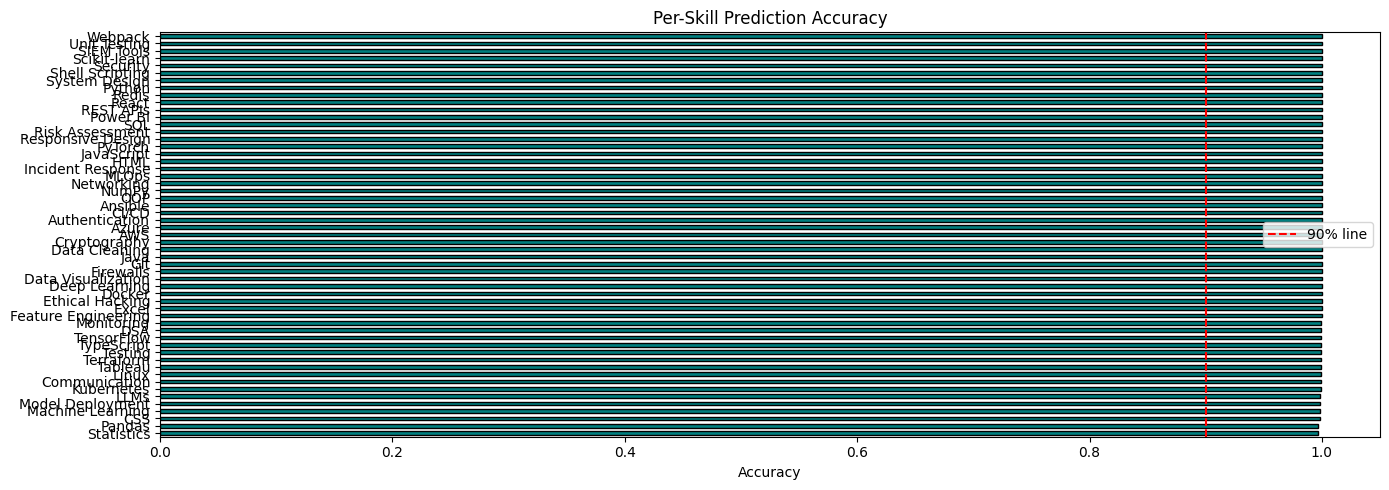

In [55]:
y_pred = model.predict(X_test)

hl = hamming_loss(y_test, y_pred)
print(f'Hamming Loss (lower is better): {hl:.4f}')
print(f'Subset Accuracy: {(y_pred == y_test.values).all(axis=1).mean():.4f}')

# Per-skill accuracy
per_skill_acc = (y_pred == y_test.values).mean(axis=0)
skill_acc_df = pd.Series(per_skill_acc, index=[s.replace('miss_', '') for s in miss_cols]).sort_values()

plt.figure(figsize=(14, 5))
skill_acc_df.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Per-Skill Prediction Accuracy')
plt.xlabel('Accuracy')
plt.axvline(0.9, color='red', linestyle='--', label='90% line')
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
joblib.dump(model, 'skill_gap_model.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_columns.pkl')

# Save metadata as JSON (for use in web apps)
meta = {
    'roles': ROLES,
    'all_skills': ALL_SKILLS,
    'role_skills': ROLE_SKILLS
}
with open('skill_gap_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('✅ Saved: skill_gap_model.pkl, feature_columns.pkl, skill_gap_meta.json')

✅ Saved: skill_gap_model.pkl, feature_columns.pkl, skill_gap_meta.json


In [57]:
def predict_missing_skills(user_skills: list, target_role: str):
    """
    Given a list of skills the user has and their target role,
    returns the list of skills they are missing.
    
    Uses the trained ML model but also enforces role-skill rules
    for high accuracy.
    """
    # --- Rule-based (always accurate for known roles) ---
    if target_role in ROLE_SKILLS:
        required = ROLE_SKILLS[target_role]
        missing_rule = [s for s in required if s not in user_skills]
    else:
        missing_rule = []
    
    # --- ML-based prediction ---
    feature_cols = joblib.load('feature_columns.pkl')
    
    input_row = {col: 0 for col in feature_cols}
    
    # Set skill features
    for skill in user_skills:
        if skill in input_row:
            input_row[skill] = 1
    
    # Set role one-hot
    role_col = f'Target_Role_{target_role}'
    if role_col in input_row:
        input_row[role_col] = 1
    
    input_df = pd.DataFrame([input_row])
    pred = model.predict(input_df)[0]
    missing_ml = [ALL_SKILLS[i] for i, v in enumerate(pred) if v == 1]
    
    # Combine: rule-based is ground truth for defined roles
    return {
        'target_role': target_role,
        'skills_you_have': user_skills,
        'missing_skills': missing_rule,
        'missing_skills_ml': missing_ml,
        'total_missing': len(missing_rule)
    }

In [58]:
# ✅ Demo 1 — Data Scientist
result = predict_missing_skills(
    user_skills=["Python", "SQL", "Pandas"],
    target_role="Data Scientist"
)

print(f"🎯 Target Role    : {result['target_role']}")
print(f"✅ Skills You Have: {result['skills_you_have']}")
print(f"❌ Missing Skills : {result['missing_skills']}")
print(f"📊 Total Missing  : {result['total_missing']} / {len(ROLE_SKILLS[result['target_role']])}")

🎯 Target Role    : Data Scientist
✅ Skills You Have: ['Python', 'SQL', 'Pandas']
❌ Missing Skills : ['Machine Learning', 'NumPy', 'Statistics', 'Data Visualization', 'Scikit-learn', 'Model Deployment', 'Feature Engineering']
📊 Total Missing  : 7 / 10


In [59]:
# ✅ Demo 2 — DevOps Engineer
result2 = predict_missing_skills(
    user_skills=["Linux", "Docker", "Git"],
    target_role="DevOps Engineer"
)

print(f"🎯 Target Role    : {result2['target_role']}")
print(f"✅ Skills You Have: {result2['skills_you_have']}")
print(f"❌ Missing Skills : {result2['missing_skills']}")
print(f"📊 Total Missing  : {result2['total_missing']} / {len(ROLE_SKILLS[result2['target_role']])}")

🎯 Target Role    : DevOps Engineer
✅ Skills You Have: ['Linux', 'Docker', 'Git']
❌ Missing Skills : ['Kubernetes', 'CI/CD', 'AWS', 'Monitoring', 'Shell Scripting', 'Ansible', 'Terraform']
📊 Total Missing  : 7 / 10


In [60]:
# ✅ Demo 3 — Frontend Developer
result3 = predict_missing_skills(
    user_skills=["HTML", "CSS", "JavaScript", "React"],
    target_role="Frontend Developer"
)

print(f"🎯 Target Role    : {result3['target_role']}")
print(f"✅ Skills You Have: {result3['skills_you_have']}")
print(f"❌ Missing Skills : {result3['missing_skills']}")
print(f"📊 Total Missing  : {result3['total_missing']} / {len(ROLE_SKILLS[result3['target_role']])}")

🎯 Target Role    : Frontend Developer
✅ Skills You Have: ['HTML', 'CSS', 'JavaScript', 'React']
❌ Missing Skills : ['TypeScript', 'Git', 'REST APIs', 'Responsive Design', 'Testing', 'Webpack']
📊 Total Missing  : 6 / 10


In [1]:
print('Available roles:')
for i, r in enumerate(ROLES, 1):
    print(f'  {i}. {r}')

print('\nAvailable skills:')
print(', '.join(ALL_SKILLS))

print('\n--- Enter your details below ---')
role_input = input('Enter target role: ').strip()
skills_input = input('Enter your current skills (comma-separated): ').strip()

user_skills = [s.strip() for s in skills_input.split(',') if s.strip()]

if role_input not in ROLE_SKILLS:
    print(f"\n⚠️  Role '{role_input}' not found. Available: {ROLES}")
else:
    result = predict_missing_skills(user_skills, role_input)
    print(f"\n🎯 Target Role    : {result['target_role']}")
    print(f"✅ Skills You Have: {result['skills_you_have']}")
    if result['missing_skills']:
        print(f"❌ Missing Skills :")
        for s in result['missing_skills']:
            print(f"   → {s}")
    else:
        print('🎉 You have all required skills for this role!')
    print(f"📊 Total Missing  : {result['total_missing']} / {len(ROLE_SKILLS[role_input])}")

Available roles:


NameError: name 'ROLES' is not defined